# PaddockTS quickstart

From a bounding box + a date range, this notebook produces:

- segmented paddock polygons (Segment Anything over an NDWI Fourier presegmentation),
- per-paddock time series of every Sentinel-2 band + NDVI / CFI / NIRv / NDTI / CAI,
- pixel-level fractional cover (bare / green / non-green vegetation),
- per-paddock seasonal phenology metrics (SoS / PoS / EoS, amplitudes, integrals),
- co-registered terrain (Copernicus DEM) and OzWALD daily climate,
- diagnostic plots, MP4 timelines, and a stitched PDF report.

All from a single `Troi` object and one `get_outputs(troi)` call.

> **Runtime.** A ~2 km AOI × 3 months takes 2–5 minutes on a laptop the first run.
> Subsequent runs with the same `Troi` are nearly instant — every stage finds its cached output and skips.

## 1. Config

PaddockTS reads config from `~/.config/Troi.json`. Defaults are sensible for a single-user laptop.

The Sentinel-2 chain works without any credentials. The SILO climate stage needs an email; SLGA soils needs a TERN API key. Both gate-keep their respective environmental steps — the rest of the pipeline runs regardless.

In [1]:
from troi import config
print(config)

------------  ------------------------------------------------
out_dir       /Users/adeel/Documents/Troi-Outputs
tmp_dir       /Users/adeel/Downloads/Troi-Tmp
hash_file     /Users/adeel/Documents/Troi-Outputs/queries.json
email         NOT SET
tern_api_key  NOT SET
------------  ------------------------------------------------


## 2. Build a `Troi`

The `Troi` (temporal region of interest) is the immutable, content-addressed object every stage consumes. It's described by a bbox in EPSG:4326 (`[west, south, east, north]`), an inclusive start date, an inclusive end date, and an optional `stub` (a short identifier used in every output filename — if omitted, a SHA-256 hash of the inputs is used).

Here we use a ~2 km AOI in southern NSW and a single quarter of 2024 — enough scenes to see the pipeline in action without a long wait.

In [2]:
from datetime import date
from troi import Troi

troi = Troi(
    bbox=[148.36265, -33.52606, 148.38265, -33.50606],   # [W, S, E, N]
    start=date(2024, 1, 1),
    end=date(2024, 3, 31),
    stub="quickstart_demo",
)
print(troi)
print("\nOutputs land under :", troi.out_dir)
print("Intermediates under :", troi.tmp_dir)

-----  --------------------------------------------
stub   quickstart_demo
bbox   [148.36265, -33.52606, 148.38265, -33.50606]
start  2024-01-01
end    2024-03-31
-----  --------------------------------------------

Outputs land under : /Users/adeel/Documents/Troi-Outputs/quickstart_demo
Intermediates under : /Users/adeel/Downloads/Troi-Tmp/quickstart_demo


## 3. Run the full pipeline

`get_outputs(troi)` spawns two worker threads — one for environmental data, one for the Sentinel-2 → PaddockTS chain — and renders a live dashboard until both finish.

Useful flags:

- `reload=True` — wipe every cached artifact for this troi and rebuild from scratch.
- `show_log=True` — show a tail-of-log panel under the status tables, handy when a stage looks stuck.
- `paddocks_filepath=...` / `skip_sam=True` — covered in `03_custom_paddocks.ipynb`.

In [3]:
from PaddockTS.get_outputs import get_outputs

get_outputs(troi)

Output()

## 4. List the outputs

By default everything lands under `~/Documents/Troi-Outputs/<stub>/`.

In [4]:
from pathlib import Path

for p in sorted(Path(troi.out_dir).iterdir()):
    size_mb = p.stat().st_size / 1e6 if p.is_file() else 0
    print(f"  {p.name:60s}  {size_mb:>6.2f} MB")

  Environmental                                                   0.00 MB
  quickstart_demo_fractional_cover.mp4                            1.26 MB
  quickstart_demo_ozwald_daily_precipitation.png                  0.06 MB
  quickstart_demo_ozwald_daily_radiation.png                      0.10 MB
  quickstart_demo_ozwald_daily_temperature.png                    0.10 MB
  quickstart_demo_ozwald_daily_wind.png                           0.12 MB
  quickstart_demo_report.pdf                                      1.95 MB
  quickstart_demo_sentinel2.mp4                                   0.61 MB
  quickstart_demo_topography.png                                  0.84 MB
  sam_paddocks_calendar_p01.png                                   0.11 MB
  sam_paddocks_calendar_p02.png                                   0.10 MB
  sam_paddocks_calendar_p03.png                                   0.09 MB
  sam_paddocks_calendar_p04.png                                   0.09 MB
  sam_paddocks_calendar_p05.png       

## 5. Open the per-paddock time series

The central data product is the `sam_paddocks_timeseries.zarr` — a `(paddock, time)` cube with one variable per Sentinel-2 band and per spectral index (NDVI, CFI, NIRv, NDTI, CAI). Downstream stages (yearly split, phenology, plots) all consume this.

In [5]:
import xarray as xr

ts = xr.open_zarr(f"{troi.tmp_dir}/sam_paddocks_timeseries.zarr",
                  decode_coords="all")
print(ts)

<xarray.Dataset> Size: 25kB
Dimensions:           (paddock: 14, time: 12)
Coordinates:
  * paddock           (paddock) <U2 112B '1' '2' '3' '4' ... '11' '12' '13' '14'
  * time              (time) datetime64[ns] 96B 2024-01-02 ... 2024-03-27
    cloud_fraction    (time) float64 96B dask.array<chunksize=(12,), meta=np.ndarray>
    snow_fraction     (time) float64 96B dask.array<chunksize=(12,), meta=np.ndarray>
    valid_fraction    (time) float64 96B dask.array<chunksize=(12,), meta=np.ndarray>
    spatial_ref       int32 4B ...
Data variables: (12/18)
    bg                (paddock, time) float64 1kB dask.array<chunksize=(14, 12), meta=np.ndarray>
    CAI               (paddock, time) float64 1kB dask.array<chunksize=(14, 12), meta=np.ndarray>
    CFI               (paddock, time) float64 1kB dask.array<chunksize=(14, 12), meta=np.ndarray>
    nbart_blue        (paddock, time) float64 1kB dask.array<chunksize=(14, 12), meta=np.ndarray>
    nbart_green       (paddock, time) float64 1kB

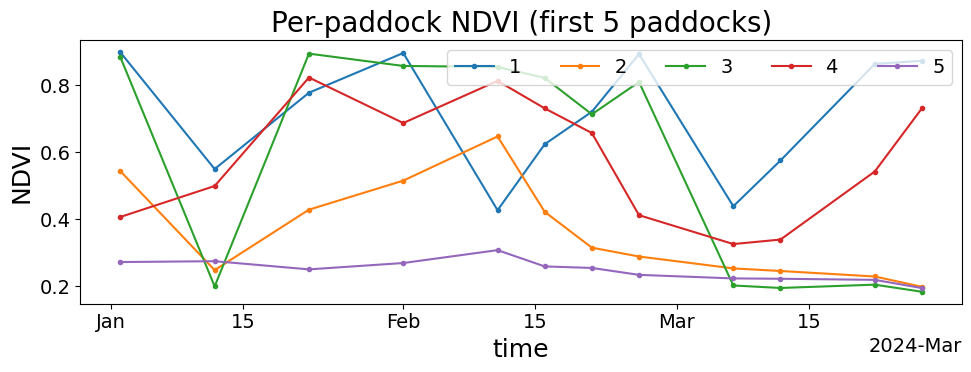

In [6]:
import io
import matplotlib.pyplot as plt
from IPython.display import Image as NBImage, display

# Note: PaddockTS.get_outputs sets matplotlib to the non-interactive 'Agg'
# backend at import time so its worker threads can render headlessly. That
# means Jupyter's inline display protocol isn't hooked into Figure objects —
# `plt.show()` is a no-op and `display(fig)` just prints the figure's repr.
# Workaround: render to a PNG buffer and display the bytes directly.
fig, ax = plt.subplots(figsize=(10, 4))
for p in ts.paddock.values[:5]:
    ts.NDVI.sel(paddock=p).plot(ax=ax, label=str(p), marker=".")
ax.set_title("Per-paddock NDVI (first 5 paddocks)")
ax.set_ylabel("NDVI")
ax.legend(ncol=5, loc="upper right")
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
plt.close(fig)
display(NBImage(data=buf.getvalue()))

## 6. Look at one of the visual outputs

The pipeline produces a per-paddock calendar PNG (one per year × page chunk) — rows are paddocks, columns are 48 evenly-spaced slots across the year, each cell is the Sentinel-2 thumbnail of that paddock at the closest observation. Useful for spotting cloud problems, cropping events, or stand-out paddocks at a glance.

sam_paddocks_calendar_p08.png


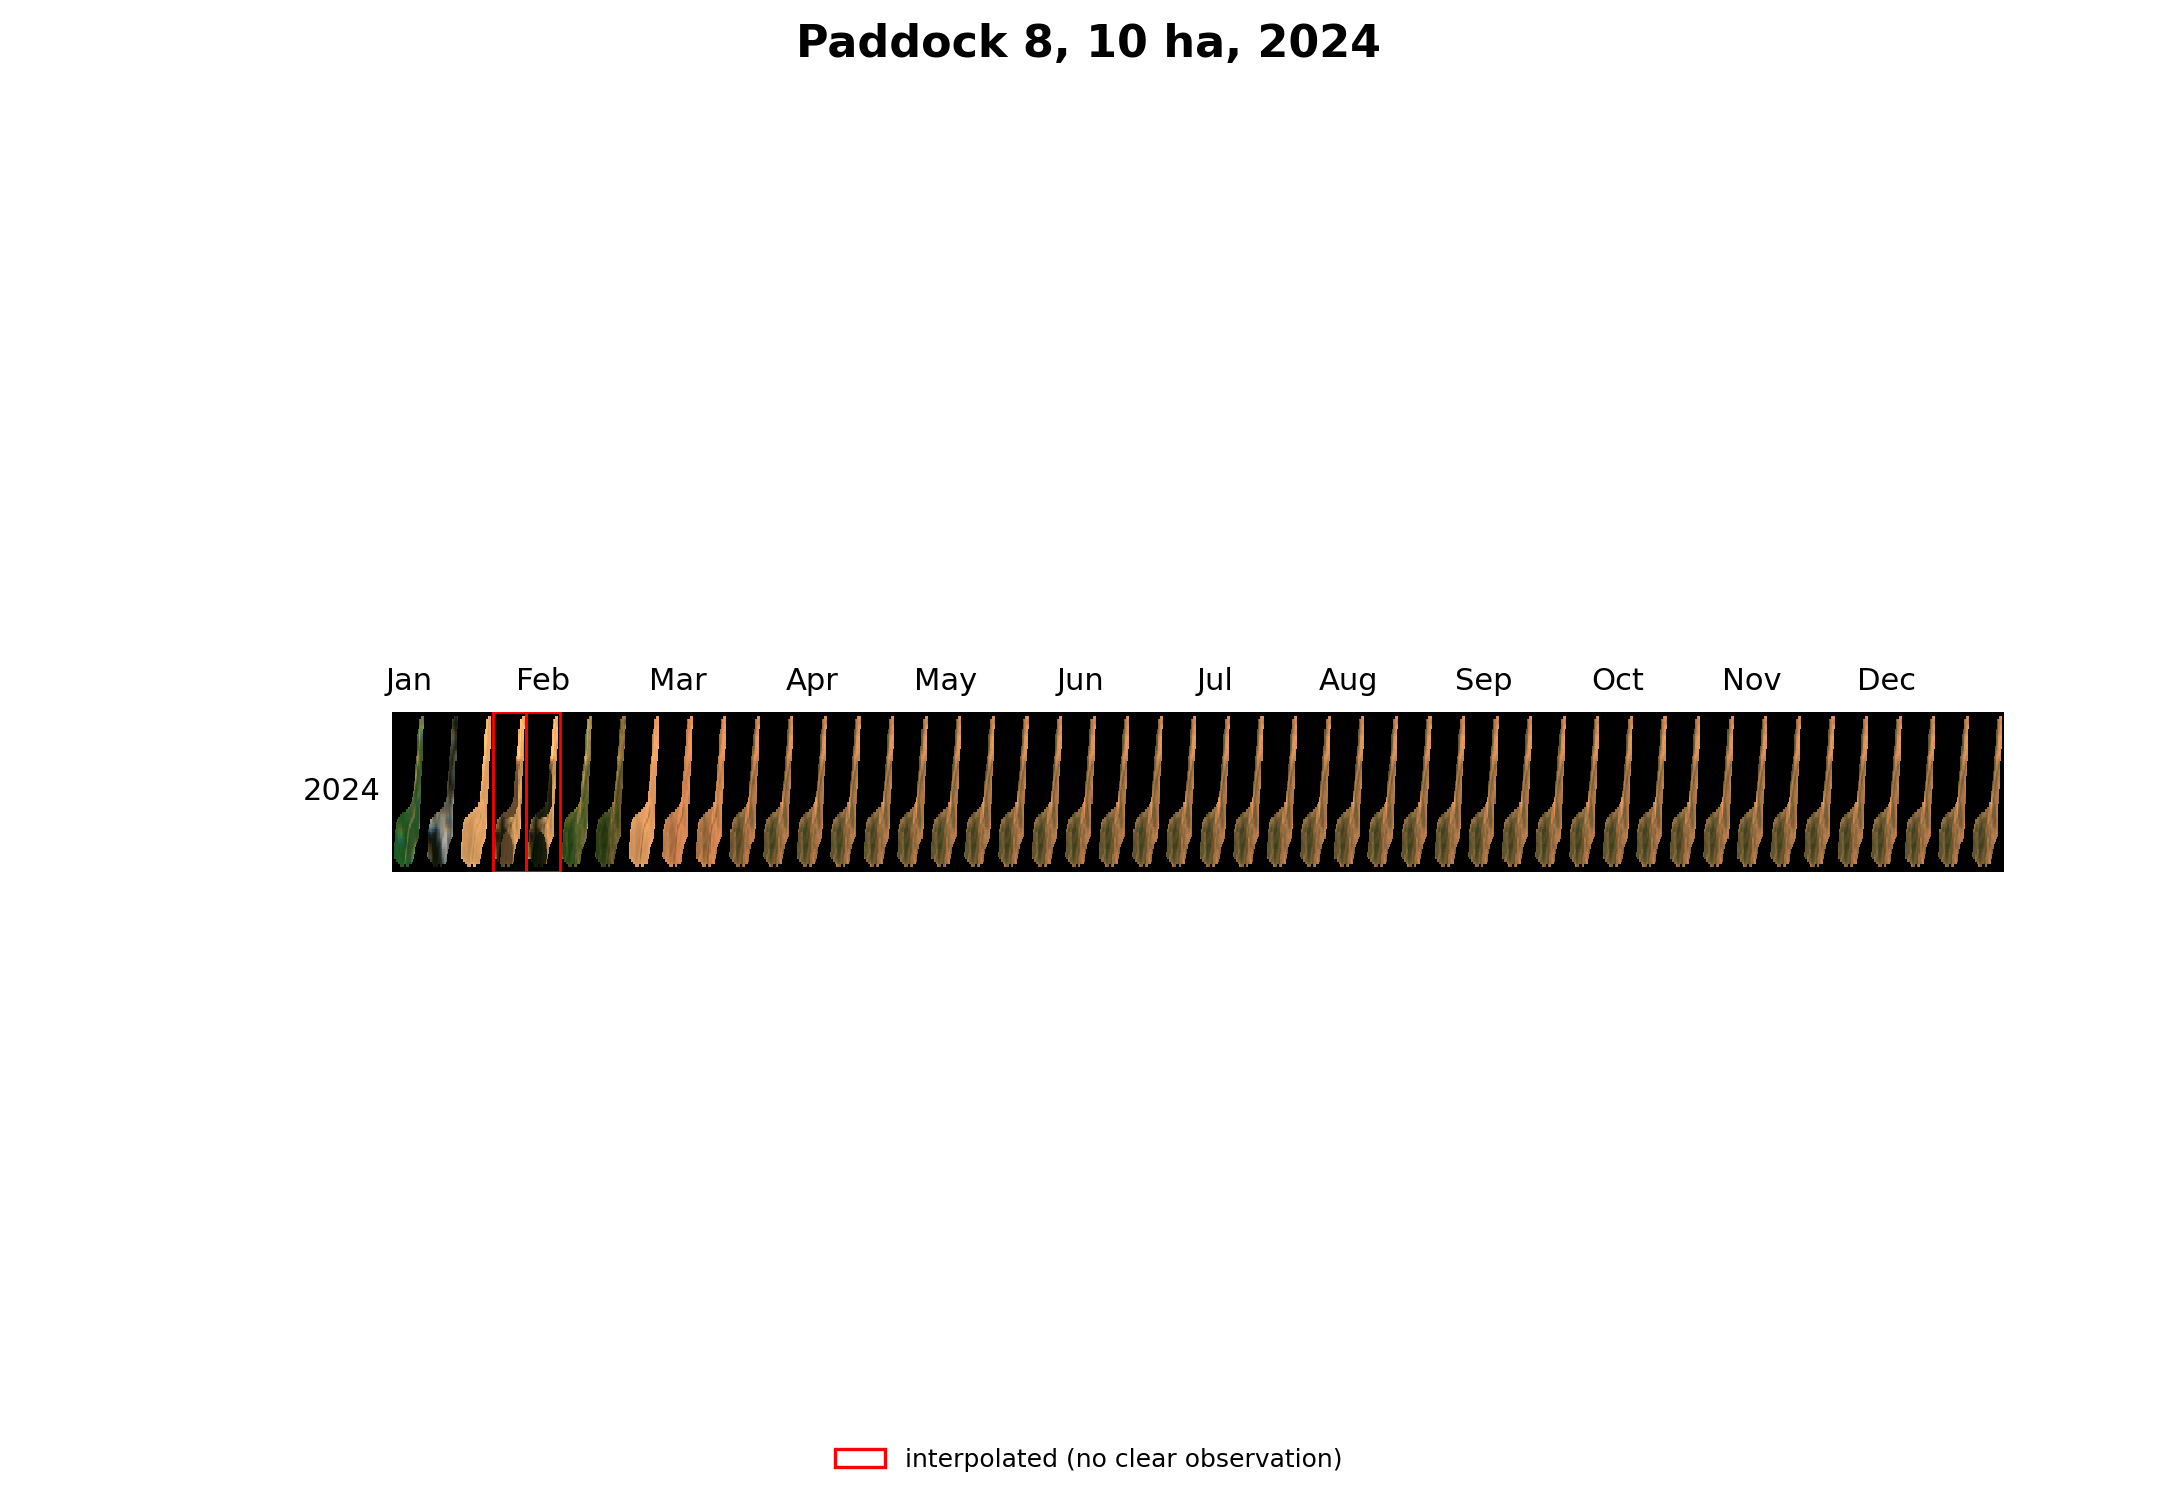

In [7]:
from IPython.display import Image as NBImage, display

cal = next(Path(troi.out_dir).glob("*_calendar_*.png"), None)
if cal:
    print(cal.name)
    display(NBImage(filename=str(cal)))
else:
    print("No calendar PNG yet — re-run get_outputs(troi).")

## 7. The stitched PDF report

Everything above (topography, climate, satellite calendar, phenology) is combined into a single landscape-A4 PDF at `{troi.out_dir}/{troi.stub}_report.pdf`. The calendar pages use vector text so labels stay readable at any zoom — see [`02_pipeline_stages.ipynb`](02_pipeline_stages.ipynb) for the details.

In [8]:
pdf = Path(troi.out_dir) / f"{troi.stub}_report.pdf"
print("PDF:", pdf, "(exists:", pdf.exists(), ")")

PDF: /Users/adeel/Documents/Troi-Outputs/quickstart_demo/quickstart_demo_report.pdf (exists: True )


## Where to next

- **[`02_pipeline_stages.ipynb`](02_pipeline_stages.ipynb)** — call each Sentinel-2 stage individually; inspect intermediate outputs.
- **[`03_custom_paddocks.ipynb`](03_custom_paddocks.ipynb)** — use your own paddock boundaries instead of SAM segmentation.
- **[Pipeline reference](https://thestochasticman.github.io/paddocktimeseries/pipeline/)** — full stage-by-stage docs.